# Chapter 6: Retrieval-Augmented Generation in Oncology

## Hands-On Jupyter Notebook

This notebook builds a compact, offline RAG pipeline for oncology evidence retrieval and grounded answer synthesis.

**Time to Complete**: 1-2 hours

**What You Will Build**
- A mini oncology evidence corpus
- Simple dense-like lexical retrieval with metadata filtering
- Grounded answer synthesis with citation tracking
- Validation checks for citation coverage and unsupported claims

---

## Section 1: Setup and Imports

This section configures utilities for indexing, retrieval, and grounded output validation.

In [1]:
import math
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

print('Environment configured for Chapter 6 RAG notebook.')

Environment configured for Chapter 6 RAG notebook.


## Section 2: Build a Mini Oncology Corpus

We define short evidence passages with metadata fields that support retrieval filtering by tumor type and evidence category.

In [2]:
corpus_df = pd.DataFrame(
    [
        {
            'doc_id': 'doc_001',
            'tumor_type': 'lung adenocarcinoma',
            'evidence_type': 'clinical_interpretation',
            'text': 'EGFR L858R in non-small cell lung cancer is commonly described as a sensitizing alteration in curated interpretation resources.',
        },
        {
            'doc_id': 'doc_002',
            'tumor_type': 'colorectal cancer',
            'evidence_type': 'cohort_context',
            'text': 'BRAF V600E in colorectal cancer can be associated with poor prognosis context and requires tumor-specific interpretation.',
        },
        {
            'doc_id': 'doc_003',
            'tumor_type': 'pediatric high-grade glioma',
            'evidence_type': 'biological_context',
            'text': 'H3F3A K27M is a defining molecular event in diffuse midline glioma and should be interpreted with pediatric disease context.',
        },
        {
            'doc_id': 'doc_004',
            'tumor_type': 'breast cancer',
            'evidence_type': 'trial_routing',
            'text': 'ERBB2 amplification may trigger trial matching workflows that require receptor status and prior therapy details.',
        },
        {
            'doc_id': 'doc_005',
            'tumor_type': 'pan-cancer',
            'evidence_type': 'governance',
            'text': 'High-impact outputs should include citation traceability, uncertainty qualifiers, and explicit human-review triggers.',
        },
    ]
)

queries_df = pd.DataFrame(
    [
        {'query_id': 'q_01', 'tumor_type': 'lung adenocarcinoma', 'query': 'EGFR sensitizing variant interpretation'},
        {'query_id': 'q_02', 'tumor_type': 'pediatric high-grade glioma', 'query': 'H3F3A K27M disease context'},
        {'query_id': 'q_03', 'tumor_type': 'breast cancer', 'query': 'ERBB2 trial matching inputs'},
        {'query_id': 'q_04', 'tumor_type': 'colorectal cancer', 'query': 'BRAF V600E prognosis caveats'},
    ]
)

display(corpus_df[['doc_id', 'tumor_type', 'evidence_type']])
display(queries_df)

,doc_id,tumor_type,evidence_type
0,doc_001,lung adenocarcinoma,clinical_interpretation
1,doc_002,colorectal cancer,cohort_context
2,doc_003,pediatric high-grade glioma,biological_context
3,doc_004,breast cancer,trial_routing
4,doc_005,pan-cancer,governance


,query_id,tumor_type,query
0,q_01,lung adenocarcinoma,EGFR sensitizing variant interpretation
1,q_02,pediatric high-grade glioma,H3F3A K27M disease context
2,q_03,breast cancer,ERBB2 trial matching inputs
3,q_04,colorectal cancer,BRAF V600E prognosis caveats


## Section 3: Retrieval and Grounded Synthesis

We implement a lightweight lexical retriever with metadata filtering and produce grounded answers citing retrieved document IDs.

In [3]:
def tokenize(text: str) -> list[str]:
    return re.findall(r'[a-z0-9]+', text.lower())

def score_query_to_doc(query: str, doc_text: str) -> float:
    q_tokens = tokenize(query)
    d_tokens = tokenize(doc_text)
    if not q_tokens or not d_tokens:
        return 0.0
    q_counts = Counter(q_tokens)
    d_counts = Counter(d_tokens)
    overlap = sum(min(q_counts[t], d_counts[t]) for t in q_counts)
    norm = math.sqrt(len(q_tokens) * len(d_tokens))
    return overlap / norm if norm > 0 else 0.0

def retrieve(query_row: pd.Series, top_k: int = 2) -> pd.DataFrame:
    scoped = corpus_df[(corpus_df['tumor_type'] == query_row['tumor_type']) | (corpus_df['tumor_type'] == 'pan-cancer')].copy()
    scoped['score'] = scoped['text'].apply(lambda t: score_query_to_doc(query_row['query'], t))
    return scoped.sort_values('score', ascending=False).head(top_k)[['doc_id', 'tumor_type', 'evidence_type', 'text', 'score']]

retrieval_rows = []
grounded_rows = []
for _, q in queries_df.iterrows():
    top_docs = retrieve(q, top_k=2)
    cited_doc_ids = top_docs['doc_id'].tolist()
    joined_snippets = ' '.join(top_docs['text'].tolist())
    answer = f"Query {q['query_id']}: {q['query']} | Evidence summary: {joined_snippets}"
    retrieval_rows.append({'query_id': q['query_id'], 'retrieved_docs': cited_doc_ids, 'max_score': float(top_docs['score'].max())})
    grounded_rows.append({'query_id': q['query_id'], 'answer': answer, 'cited_doc_ids': cited_doc_ids})

retrieval_df = pd.DataFrame(retrieval_rows)
grounded_df = pd.DataFrame(grounded_rows)

display(retrieval_df)
display(grounded_df[['query_id', 'cited_doc_ids']])

,query_id,retrieved_docs,max_score
0,q_01,"[doc_001, doc_005]",0.344124
1,q_02,"[doc_003, doc_005]",0.458831
2,q_03,"[doc_004, doc_005]",0.387298
3,q_04,"[doc_002, doc_005]",0.363803


,query_id,cited_doc_ids
0,q_01,"[doc_001, doc_005]"
1,q_02,"[doc_003, doc_005]"
2,q_03,"[doc_004, doc_005]"
3,q_04,"[doc_002, doc_005]"


## Section 4: Retrieval Quality Visualization

We compare retrieval confidence by query and inspect per-query top score distribution.

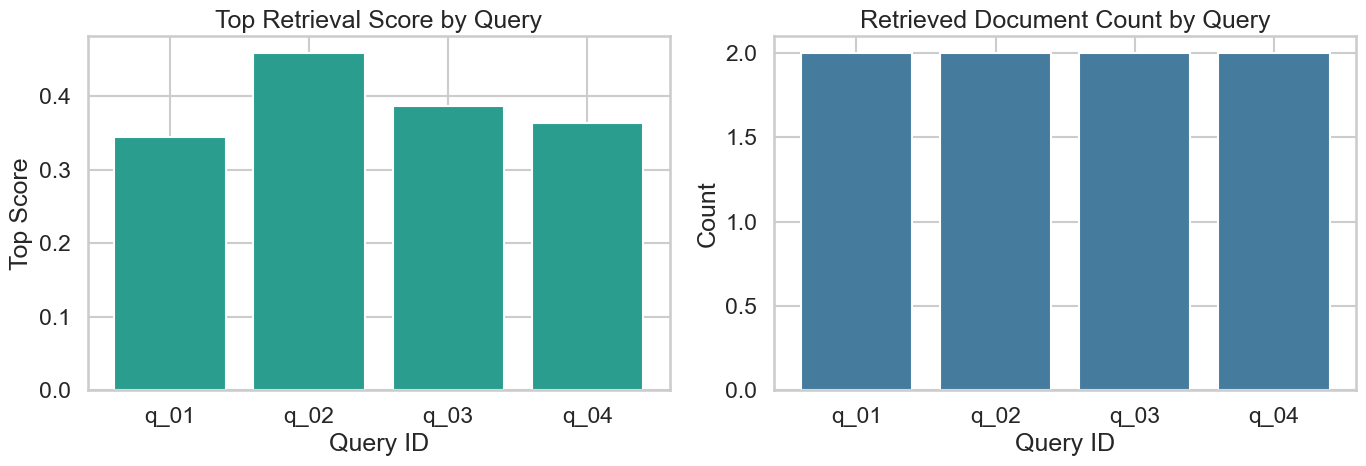

,query_id,retrieved_docs,max_score
0,q_01,"[doc_001, doc_005]",0.344124
1,q_02,"[doc_003, doc_005]",0.458831
2,q_03,"[doc_004, doc_005]",0.387298
3,q_04,"[doc_002, doc_005]",0.363803


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(retrieval_df['query_id'], retrieval_df['max_score'], color='#2A9D8F')
axes[0].set_title('Top Retrieval Score by Query')
axes[0].set_xlabel('Query ID')
axes[0].set_ylabel('Top Score')

doc_count = retrieval_df['retrieved_docs'].apply(len)
axes[1].bar(retrieval_df['query_id'], doc_count, color='#457B9D')
axes[1].set_title('Retrieved Document Count by Query')
axes[1].set_xlabel('Query ID')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

display(retrieval_df)

## Section 5: Exercises

### Exercise 1: Citation Coverage Validator

Validate that each grounded answer cites at least one retrieved document and all cited IDs are present in the corpus.

In [5]:
valid_doc_ids = set(corpus_df['doc_id'])

def validate_citations(cited_ids: list[str]) -> dict[str, object]:
    if len(cited_ids) == 0:
        return {'has_citation': False, 'unknown_ids': []}
    unknown = [d for d in cited_ids if d not in valid_doc_ids]
    return {'has_citation': True, 'unknown_ids': unknown}

coverage_rows = []
for _, row in grounded_df.iterrows():
    check = validate_citations(row['cited_doc_ids'])
    coverage_rows.append({
        'query_id': row['query_id'],
        'has_citation': check['has_citation'],
        'unknown_ids': check['unknown_ids'],
    })

coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df)

,query_id,has_citation,unknown_ids
0,q_01,True,[]
1,q_02,True,[]
2,q_03,True,[]
3,q_04,True,[]


### Exercise 2: Retrieval Router

Route each query to a retrieval policy (strict_tumor_scope or broad_scope) based on query intent and tumor specificity.

In [6]:
def choose_policy(query_text: str) -> str:
    q = query_text.lower()
    if any(k in q for k in ['prognosis', 'sensitizing', 'context']):
        return 'strict_tumor_scope'
    return 'broad_scope'

policy_df = queries_df[['query_id', 'query', 'tumor_type']].copy()
policy_df['policy'] = policy_df['query'].apply(choose_policy)
policy_df['expected_top_k'] = np.where(policy_df['policy'] == 'strict_tumor_scope', 2, 3)

display(policy_df)
print('Policies assigned for all queries.')

,query_id,query,tumor_type,policy,expected_top_k
0,q_01,EGFR sensitizing variant interpretation,lung adenocarcinoma,strict_tumor_scope,2
1,q_02,H3F3A K27M disease context,pediatric high-grade glioma,strict_tumor_scope,2
2,q_03,ERBB2 trial matching inputs,breast cancer,broad_scope,3
3,q_04,BRAF V600E prognosis caveats,colorectal cancer,strict_tumor_scope,2


Policies assigned for all queries.


## Section 6: Key Takeaways

- RAG pipelines in oncology should combine relevance scoring with metadata-aware filtering.
- Grounded answers must carry explicit citation IDs for auditability.
- Retrieval quality should be monitored per-query, not only in aggregate.
- Citation coverage validation is a lightweight but high-impact safety check.
- Policy-based routing helps align retrieval behavior with query intent and risk level.


## Next Steps

1. Replace lexical scoring with embedding-based retrieval for semantic robustness.
2. Add conflict-aware synthesis when retrieved evidence disagrees.
3. Persist retrieval and coverage tables for cross-chapter evaluation.
4. Reuse retrieval policies in multi-agent orchestration chapters.


**Last Updated**: May 2026